## RBF-PU Spectral Method

In [3]:
import numpy as np
from rbf.pde.nodes import poisson_disc_nodes
from PuHelper import *
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [4]:
#Params
epsilon = 2
delta = 0.01
nodes_in_patch= 200
overlap = 3

In [5]:
vert = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
edges = np.array([[0, 1], [1, 2], [2, 3], [3, 0]])
nodes, groups, _ = poisson_disc_nodes(delta, (vert, edges))

In [6]:
interior_nodes = nodes[groups['interior']]
boundary_nodes = nodes[groups['boundary:all']]

nodes = np.vstack((interior_nodes, boundary_nodes))
min_boundary_idx = len(interior_nodes)


In [7]:
centers = GenCenters(nodes, nodes_in_patch, overlap)
patches, radii, node_to_patch = GenPatches(nodes, centers, nodes_in_patch)

phis = GenLocalPhi(nodes, patches, epsilon)
grads = GenLocalGrads(nodes, patches, phis, epsilon)
laps = GenLocalLaps(nodes, patches, phis, epsilon)

In [16]:
# First Dirichlet eigenfunction on [0,1]x[0,1]
u_exact = np.sin(np.pi * nodes[:, 0]) * np.sin(np.pi * nodes[:, 1])

# If your PDE is -Δu = f:
f = 2 * np.pi**2 * u_exact
# (If your PDE is Δu = f, use: f = -2 * np.pi**2 * u_exact)

u, info, _ = SolvePoissonGMRES(f.copy(), nodes, patches, centers, radii, grads, laps, boundary_idx=min_boundary_idx, rtol=1e-5)

C:\Users\alexs\AppData\Local\Temp\ipykernel_50756\723321291.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


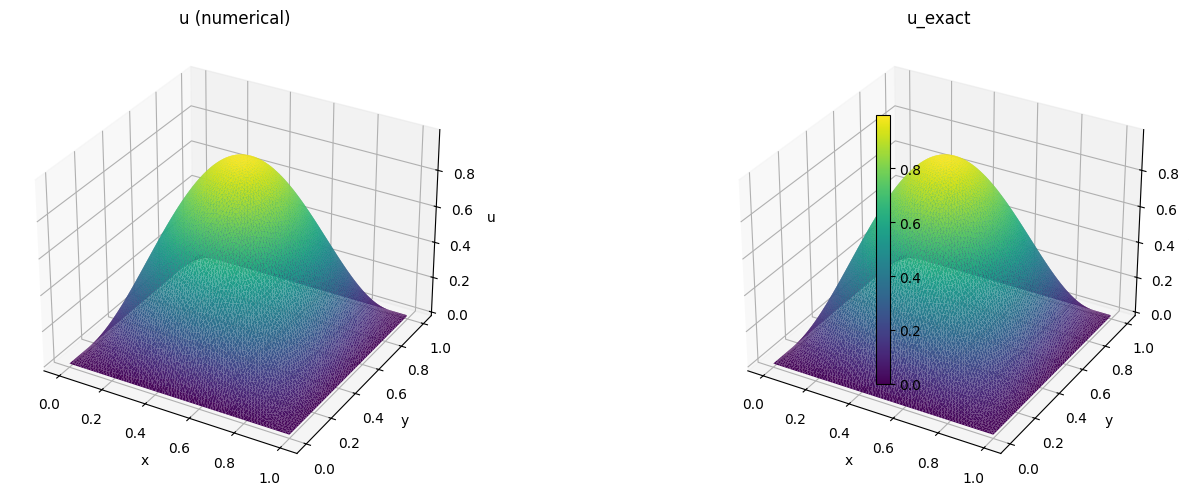

In [13]:
import matplotlib.tri as mtri

x, y = nodes[:, 0], nodes[:, 1]
triang = mtri.Triangulation(x, y)

vmin = min(u.min(), u_exact.min())
vmax = max(u.max(), u_exact.max())

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_trisurf(triang, u, cmap='viridis', vmin=vmin, vmax=vmax, linewidth=0.1)
ax1.set_title("u (numerical)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_trisurf(triang, u_exact, cmap='viridis', vmin=vmin, vmax=vmax, linewidth=0.1)
ax2.set_title("u_exact")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("u_exact")

fig.colorbar(surf2, ax=[ax1, ax2], shrink=0.7, pad=0.08)
plt.tight_layout()
plt.show()

In [17]:
print(f"GMRES info: {info}")

GMRES info: 0
